In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn import tree
from sklearn.metrics import confusion_matrix, classification_report


import matplotlib.pyplot as plt
%matplotlib inline
import pickle


In [ ]:
df = pd.read_csv('car_evaluation.csv')

In [ ]:
df.head()

,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


In [ ]:
df.tail()

,buying,maint,doors,persons,lug_boot,safety,class
1723,low,low,5more,more,med,med,good
1724,low,low,5more,more,med,high,vgood
1725,low,low,5more,more,big,low,unacc
1726,low,low,5more,more,big,med,good
1727,low,low,5more,more,big,high,vgood


In [ ]:
df['class'].value_counts()


,count
class,
unacc,1210
acc,384
good,69
vgood,65


In [ ]:
df['buying'].value_counts()


,count
buying,
vhigh,432
high,432
med,432
low,432


In [ ]:
df['maint'].value_counts()


,count
maint,
vhigh,432
high,432
med,432
low,432


In [ ]:
df['doors'].value_counts()


,count
doors,
2,432
3,432
4,432
5more,432


In [ ]:
df['persons'].value_counts()


,count
persons,
2,576
4,576
more,576


In [ ]:
df['lug_boot'].value_counts()


,count
lug_boot,
small,576
med,576
big,576


In [ ]:
df['safety'].value_counts()


,count
safety,
low,576
med,576
high,576


In [ ]:
df.isnull().sum()


,0
buying,0
maint,0
doors,0
persons,0
lug_boot,0
safety,0
class,0


In [ ]:
X = df.drop(['class'], axis=1)

y = df['class']

In [ ]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.33, random_state = 42)

In [ ]:
X_train.shape, X_test.shape


((1157, 6), (571, 6))

In [ ]:
cols=['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety']
oe = OrdinalEncoder()
df[cols] = oe.fit_transform(df[cols])
print(df)



      buying  maint  doors  persons  lug_boot  safety  class
0        3.0    3.0    0.0      0.0       2.0     1.0  unacc
1        3.0    3.0    0.0      0.0       2.0     2.0  unacc
2        3.0    3.0    0.0      0.0       2.0     0.0  unacc
3        3.0    3.0    0.0      0.0       1.0     1.0  unacc
4        3.0    3.0    0.0      0.0       1.0     2.0  unacc
...      ...    ...    ...      ...       ...     ...    ...
1723     1.0    1.0    3.0      2.0       1.0     2.0   good
1724     1.0    1.0    3.0      2.0       1.0     0.0  vgood
1725     1.0    1.0    3.0      2.0       0.0     1.0  unacc
1726     1.0    1.0    3.0      2.0       0.0     2.0   good
1727     1.0    1.0    3.0      2.0       0.0     0.0  vgood

[1728 rows x 7 columns]


In [ ]:
X_train = oe.fit_transform(X_train)

X_test = oe.transform(X_test)

In [ ]:
df['doors'].value_counts()


,count
doors,
0.0,432
1.0,432
2.0,432
3.0,432


In [ ]:
X_train


array([[3., 3., 1., 2., 1., 1.],
       [0., 3., 1., 1., 2., 1.],
       [3., 0., 1., 2., 2., 0.],
       ...,
       [0., 1., 3., 2., 1., 0.],
       [1., 0., 2., 0., 2., 2.],
       [2., 2., 1., 2., 2., 2.]])

In [ ]:
#clf = DecisionTreeClassifier(criterion='entropy', random_state=0)
clf = DecisionTreeClassifier(criterion='entropy', max_depth=9, random_state=0)


# fit the model
clf.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=9, random_state=0)

In [ ]:
y_pred = clf.predict(X_test)


In [ ]:

print('Model accuracy score: {0:0.4f}'. format(accuracy_score(y_test, y_pred)))


Model accuracy score: 0.9405


**Compare** the train-set and test-set accuracy
Now, I will compare the train-set and test-set accuracy to check for overfitting.

In [ ]:
y_pred_train = clf.predict(X_train)

y_pred_train

array(['unacc', 'unacc', 'unacc', ..., 'acc', 'unacc', 'acc'],
      dtype=object)

In [ ]:
print('Training-set accuracy score: {0:0.4f}'. format(accuracy_score(y_train, y_pred_train)))


Training-set accuracy score: 0.9767


In [ ]:
# print the scores on training and test set

print('Training set score: {:.4f}'.format(clf.score(X_train, y_train)))

print('Test set score: {:.4f}'.format(clf.score(X_test, y_test)))

Training set score: 0.9767
Test set score: 0.9405


Our model is likely slightly overfitting, but the overfitting is minimal because the test accuracy is still very close to the training accuracy.

This is typical of decision trees, which can easily overfit if grown fully without pruning


[Text(0.5452302631578947, 0.95, 'x[3] <= 0.5\nentropy = 1.2\nsamples = 1157\nvalue = [255, 49, 813, 40]'),
 Text(0.5276864035087719, 0.85, 'entropy = 0.0\nsamples = 375\nvalue = [0, 0, 375, 0]'),
 Text(0.5364583333333333, 0.8999999999999999, 'True  '),
 Text(0.5627741228070176, 0.85, 'x[5] <= 0.5\nentropy = 1.465\nsamples = 782\nvalue = [255, 49, 438, 40]'),
 Text(0.5540021929824561, 0.8999999999999999, '  False'),
 Text(0.31743421052631576, 0.75, 'x[1] <= 2.5\nentropy = 1.684\nsamples = 263\nvalue = [139, 21, 63, 40]'),
 Text(0.1787280701754386, 0.65, 'x[0] <= 0.5\nentropy = 1.668\nsamples = 194\nvalue = [108.0, 21.0, 25.0, 40.0]'),
 Text(0.05263157894736842, 0.55, 'x[2] <= 0.5\nentropy = 0.232\nsamples = 53\nvalue = [51, 0, 2, 0]'),
 Text(0.03508771929824561, 0.45, 'x[4] <= 1.5\nentropy = 0.65\nsamples = 12\nvalue = [10, 0, 2, 0]'),
 Text(0.017543859649122806, 0.35, 'entropy = 0.0\nsamples = 8\nvalue = [8, 0, 0, 0]'),
 Text(0.05263157894736842, 0.35, 'x[3] <= 1.5\nentropy = 1.0\nsamp

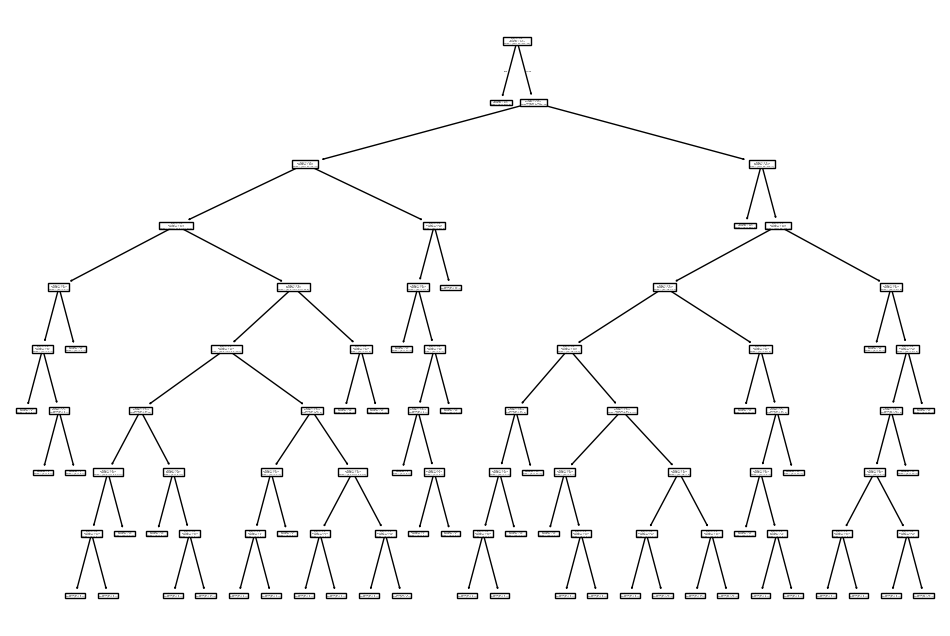

In [ ]:
plt.figure(figsize=(12,8))

tree.plot_tree(clf.fit(X_train, y_train))

In [ ]:
class_counts = y_train.value_counts()
print("Class counts in y_train:")
print(class_counts)

Class counts in y_train:
class
unacc    813
acc      255
good      49
vgood     40
Name: count, dtype: int64


In [ ]:
class_counts = y_test.value_counts()
print("Class counts in y_test:")
print(class_counts)

Class counts in y_train:
class
unacc    397
acc      129
vgood     25
good      20
Name: count, dtype: int64


Confusion Matrix:
[[109  17   2   1]
 [  3  15   0   2]
 [  4   2 391   0]
 [  3   0   0  22]]


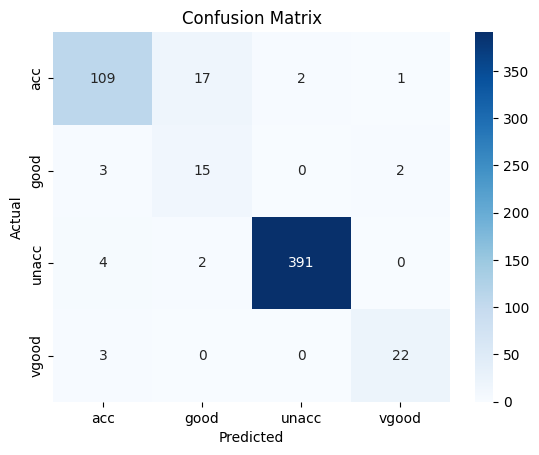


Classification Report:
              precision    recall  f1-score   support

         acc       0.92      0.84      0.88       129
        good       0.44      0.75      0.56        20
       unacc       0.99      0.98      0.99       397
       vgood       0.88      0.88      0.88        25

    accuracy                           0.94       571
   macro avg       0.81      0.86      0.83       571
weighted avg       0.95      0.94      0.94       571



In [ ]:
# Generate the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

# Plot the confusion matrix
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
             xticklabels=clf.classes_, yticklabels=clf.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Classification report
report = classification_report(y_test, y_pred, target_names=clf.classes_)
print("\nClassification Report:")
print(report)